# Local Search
## Eight Queens
### Introduction

<figure>
<img src="resources/eight_queens_moves.png", width=300 align="right">
    <figcaption></figcaption>
</figure>

The [Eight Queens puzzle](https://en.wikipedia.org/wiki/Eight_queens_puzzle) is a famous puzzle that has been studied extensively in- and outside of computer science. It was first published in the chess magazine _Schach_ in 1848. 

The problem can be formulated as follows: 

_"Place 8 queens on a regular (8x8) chess board such that no queen attacks any other queen."_

A queen in the game of chess can move horizontally, vertically, and diagonally. The puzzle can be solved by hand (and even [Carl Friedrich Gauss](https://en.wikipedia.org/wiki/Carl_Friedrich_Gauss) studied it back in 1850).

### Eight Queens Code
Before we attempt any algorithmic solution, we need a way to model the Eight Queens puzzle: the board, the valid moves, and so on.

We could use a 2D array to represent the chessboard. However we get some automatic benefits if we use another representation. Specifically, we will use a 1D array of size 8. Each cell in the array stores the location of the queen in that column. This means the board state itself enforces one of the rules of the game, it is not possible to put two queens in one column.

So the following board:
```
   01234567
7  .X......
6  .....X..
5  X.......
4  ..X.....
3  .......X
2  ....X...
1  ......X.
0  ...X....
```
would be represented by the following array:
`[5, 7, 4, 0, 2, 6, 1, 3]`

We'll use numpy for this example, so it will actually be:

In [1]:
import numpy as np
np.array([5, 7, 4, 0, 2, 6, 1, 3], dtype=int)

array([5, 7, 4, 0, 2, 6, 1, 3])

Notice that the board above is not a valid arrangement. The two queens highlighted with `O` symbols are attacking each other.

```
   01234567
7  .X......
6  .....X..
5  X.......
4  ..O.....
3  .......X
2  ....O...
1  ......X.
0  ...X....
```

Being able to actually model the problem we are trying to solve is a necessary part of writing AI code. You can spend surprisingly long just implementing the rules of the puzzle, but without this step you cannot hope to solve it! Sometimes we will provide code to help, as in the Tower of Hanoi example. But you will often need to modify or create your own from scratch. So it's important to take some time to understand how this code works.

The code below implements the board state for the eight queens puzzle. It includes a method which can calculate the cost heuristic – in this case, the number of pairs of attacking queens. It also has methods which generate neighbouring states, which are states with exactly one queen moved within its column.

In [2]:
class EightQueensState:
    """This class represents a board in the eight queens puzzle

        REPRESENTATION (the key idea):
        state is an array of n integers.
        INDEX = column, VALUE = row.

        state = [2, 5, 0, ...] means:
            queen in column 0 is on row 2
            queen in column 1 is on row 5
            queen in column 2 is on row 0
    
        Because there is exactly one value per column, two queens can never
        share a column. So we only ever have to check rows and diagonals.
        This shrinks the search space from ~4.4 billion boards to 8^8 = 16.7m."""
    def __init__(self, state=None, n=8):
        """
        :param state: pass in a numpy array of integers to set the state, otherwise will be generated randomly
        :param n: only used if state is not provided, determines size of board (default: 8)
        """
        if state is None:
            self.n = n
            # randint(low, high, size) -> `size` numbers drawn from [low, high)
            # so randint(0, 8, 8) gives 8 numbers, each between 0 and 7.
            #   first n  = number of ROWS    (valid row values are 0..n-1)
            #   second n = number of COLUMNS (we need one queen per column)
            # NB: low is inclusive, high is EXCLUSIVE - that's why it's n, not n-1.
            state = np.random.randint(0, n, n)
        else:
            # If you do pass a state, n is inferred from its length and the n argument is ignored
            self.n = len(state)
        self.state = state

    @staticmethod # no `self` - this doesn't look at the board, so it doesn't need one
    def copy_replace(state, i, x):
        #It means: move the queen in column i to row x, but on a fresh copy of the board rather than the original
        #Remember index = column, value = row. So i is which queen (which column she's in) and x is where she goes (which row)
        """This creates a copy of the state (important as numpy arrays are mutable) with column i set to x
        
        The copy matters: numpy arrays are mutable. Without .copy() we'd be
        editing the original array in place, and every neighbour we generated
        would end up pointing at the same board.
        """
        new_state = state.copy()
        new_state[i] = x
        return new_state

    @staticmethod # pure arithmetic - nothing to do with queens at all so staticmethod makes sense here
    def range_missing(start, stop, missing):
        """
        A range with one value left out.
            range_missing(0, 8, 2) -> [0, 1, 3, 4, 5, 6, 7]

        Used when moving a queen within its column: we want every row EXCEPT
        the one it's already sitting on, since "moving" it there isn't a move.
        """
        #The '+' glues the lists together to make one list
        #The return builds the list in two pieces, then sticks them together with the 'missing' value always skipped:
        return list(range(start, missing)) + list(range(missing + 1, stop))

    def cost(self):
        """
        The heuristic: how bad is this board? 0 means solved.

        Three yes/no questions per queen, each worth 1.
        """
        count = 0
        for i in range(len(self.state) - 1):
            # for each queen, look in columns to the right:
            # --- ROW CLASH: is any queen to the right on the same row? ---
            # np.any asks "was there at least one True?" and gives back a single True or False. True counts as 1 when added.
            count += np.any(self.state[i + 1:] == self.state[i])

            # --- DIAGONAL CLASH ---
            # A diagonal is just "one step across, one step up."
            # A queen in column j (to the right of i) is on i's upper diagonal if its row == state[i] + (j - i). So build the list of rows that
            # WOULD be attacked, one entry per column to the right:
            # The queen in question is in column 0, row 2:
            # her row — where to count from
            # [1,2,3,4,5,6,7]        gaps — how far across
            # [3,4,5,6,7,8,9] rows — the hit list. Seven dangerous rows, one for each column to the right:
            #   state[i] = 2, n = 8, i = 0
            #   -> 2 + [1,2,3,4,5,6,7] = [3,4,5,6,7,8,9]
            #
            # This vector is the same length as state[i+1:] and the positions
            # line up, so the == below compares every column at once.
            # Values that fall off the board (8, 9) are harmless - no queen
            # can have those row values, so they just never match.
            upper_diagonal = self.state[i] + np.arange(1, self.n - i)   # build the up-and-right hit list.
            lower_diagonal = self.state[i] - np.arange(1, self.n - i)   # same thing downwards. Only the sign changes so the Down-and-right hit list
            # Lines 3 and 4 below: — compare each hit list against reality:
            count += np.any(self.state[i + 1:] == upper_diagonal)
            count += np.any(self.state[i + 1:] == lower_diagonal)
        return count

    def neighbourhood(self):
        """Every board reachable by moving ONE queen within its own column.

        n columns x (n-1) other rows = 56 neighbours for the 8-queens board.
        This is the full move set for steepest-ascent hill climbing: evaluate
        all 56, take the best.
        """
        neighbourhood = []
        for column in range(self.n):
            # every row in this column except the one currently occupied:
            # passing self.state[column] to range_missing is what guarantees current row is left out
            for new_position in self.range_missing(0, self.n, self.state[column]):
                # a fresh board copy is created for EACH new_position, so the
                # 7 boards from this column are 7 separate arrays. Without the
                # copy inside copy_replace they'd all be the same array and we'd
                # end up with 56 references to one board.
                # Note: self.state — the current board. The one you're standing on.
                new_state = self.copy_replace(self.state, column, new_position)
                neighbourhood.append(EightQueensState(new_state))

        return neighbourhood

    def random_neighbour(self):
        """
        One neighbour picked at random from the same 56 moves that
        neighbourhood() would generate - but WITHOUT BUILDING all 56.

        Needed by simulated annealing and stochastic hill climbing, which only
        look at ONE candidate per step. Generating 56 and throwing away 55
        would be wasted work.
        """
        # DRAW 1: pick a queen at random. range(8) -> [0..7], choose one.
        column = np.random.choice(range(self.n))

        # DRAW 2: pick where she goes. Same candidate list neighbourhood() uses
        # (every row except the one she's on), but take one at random instead
        # of looping through all seven.
        new_position = np.random.choice(self.range_missing(0, self.n, self.state[column])) # instead of looping, just picks one at random
        # Note: self.state — the current board. The one you're standing on.
        new_state = self.copy_replace(self.state, column, new_position)
        return EightQueensState(new_state)

        # NOTE: nothing here looks at cost. This is an ARBITRARY neighbour,
        # not a good one - it may well be worse than the current board.
        # That's deliberate: simulated annealing needs an unbiased draw because
        # sometimes accepting a worse move is how it escapes local optima.
        # Always handing it the best neighbour would just make it hill climbing.

    def is_goal(self):
        # no attacks anywhere = a valid solution
        return self.cost() == 0

    def __str__(self):
        # lets you print(state) inside a search loop and watch the cost fall
        if self.is_goal():
            return f"Goal state! {self.state}"
        else:
            return f"{self.state} cost {self.cost()}"

Read the code before moving on. You should at least understand what each method does (e.g. from its name, parameters, and docstring) but you may also want to read some of the implementation.

In [3]:
state = EightQueensState() # make a random board
print(state) # show it - triggers __str__, which calls cost()
print(state.is_goal()) # ask: is cost 0?  ->  False

[1 6 4 2 0 3 7 7] cost 2
False


### Hill Climbing
Hill-climbing search (Section 4.1.1 in R&N) is a very general and intuitive class of algorithms. Hill-climbing methods can be applied if one is able to assign a _value_ to each state on the search path. The algorithm then continuously moves towards higher-valued states (that is, climbing uphill). The algorithm terminates if there is no higher-valued state in the current neighbourhood.

<figure>
<img src="resources/hill_climbing_no_capt.png", width=600>
<center>Figure 1. Pseudocode of the hill-climbing algorithm taken from Russell and Norvig (p.122). <br> At each step the current node is replaced by the best neighbour.</center>
</figure>
<br>

Notice that since we are using a *cost function* for our heuristic (smaller values are good), what we really want to do is climb *“downhill”*. We will adapt the pseudocode to achieve this.

We already have our state representation, so now let's write the code which does the hill climbing.

### Note to self: why "climbing" when we're minimising?

**Hill climbing is named for the maximising version.** You have a *value*
function, and you climb toward higher values. That's the metaphor, and it's
why R&N say "higher-valued states".

**But many problems come with a cost function instead** — queens conflicts,
distance, error — and those you want to *minimise*.

**They're the same algorithm.** Negate the function and a valley becomes a hill:

| step | cost (minimise) | value = −cost (maximise) |
|---|---|---|
| 1 | 6 | −6 |
| 2 | 4 | −4 |
| 3 | 2 | −2 |
| 4 | 0 | 0 |

Identical search, identical decisions. Only the sign changed.

Hence the same procedure gets called hill climbing, gradient descent, steepest
ascent, steepest descent, or greedy local search, depending on whose sign
convention is in play.

**Upshot for this notebook:** we have `cost()`, so we are minimising. The loop
wants `min` and `<`, not `max` and `>`:

```python
best = min(neighbours, key=lambda s: s.cost())
```

Read R&N's "higher-valued" as "better" and the shape of the algorithm is the
same either way: look around, move to the best neighbour, stop when nothing
nearby is better.

In [4]:
class HillClimber:
    """Applies the hill climbing algorithm to solve the 8 queens puzzle"""
    def __init__(self, state=EightQueensState()):
        # WARNING - mutable default argument. Python evaluates EightQueensState()
        # ONCE, when this def line is read, not on each call. So every
        # HillClimber() created without an argument shares the SAME board.
        # Fine here because we always pass state in, but if you loop
        # `HillClimber()` to gather stats every run starts identically.
        # Safer: state=None, then `if state is None: state = EightQueensState()`
        self.state = state
        #state.n is the board size, and on a standard 8-queens board it's just 8
        # not used below, there's no reason for it in the code
        self.n = state.n 

    @staticmethod # # doesn't touch the climber (the object isn't needed), only the board passed in
    def best_neighbour(state):
        """Gets all neighbours from the state, then returns the one with lowest cost"""
        # neighbourhood() builds all 56 boards; min picks one.
        # key=lambda x: x.cost() tells min WHAT to compare - board objects have no natural ordering, so we order them by their cost value.
        # 56 cost() evaluations per step. That's what makes this STEEPEST DESCENT - look at every option before moving. (R&N call it
        # steepest-ASCENT because their framing maximises a value; we minimise cost, so we descend. Same algorithm, opposite sign.)
        return min(state.neighbourhood(), key=lambda x: x.cost())

    def hill_climb(self):
        """
        Repeatedly take the best neighbour of each state until we find a solution (or get stuck)
        :returns a goal state OR a local minimum (if all options are worse than the current one but it is not a goal)
        """
        # lucky case: the random starting board was already a solution
        if self.state.is_goal():
            return self.state

        while True:
            # look at all 56 neighbours, take the best one
            neighbour = HillClimber.best_neighbour(self.state)

            # solved - stop immediately
            if neighbour.is_goal():
                return neighbour
            
            # STRICTLY better (<, not <=) so equal-cost sideways moves are
            # refused. This prevents infinite shuffling on a plateau, but it
            # also means plateaus end the search rather than being crossed.
            # The usual fix is to allow sideways moves but cap them. In R&N's analysis, allowing up to 100 sideways moves takes 8-queens success from around 14% to around 94%
            if neighbour.cost() < self.state.cost():
                self.state = neighbour
            else:
                # notice the method gives up if there are no better options
                # This is the defining weakness: no sideways moves, no downhill
                # moves, no restarts. Returns a LOCAL MINIMUM (often cost 1 or 2),
                # local minimum: a board where every single-queen move makes things the same or worse, but the board still isn't solved.
                # NOT a solution. Always check the cost of what comes back.
                return self.state

state = EightQueensState()
climber = HillClimber(state)
solution = climber.hill_climb()
print(solution) # may print "cost 1" etc - that's a failure, not a bug

[2 5 7 4 1 3 0 6] cost 1


As always, take some time to read and fully understand the code.

When I ran the code above, the following solution was found: `[3 1 7 5 0 2 4 6]`. Here it is visualised on a board:
```
   01234567
7  ..X.....
6  .......X
5  ...X....
4  ......X.
3  X.......
2  .....X..
1  .X......
0  ....X...
```

Looks great, right! But there's a problem. Try running the solver again, and you might get something like this:

In [5]:
state = EightQueensState()
climber = HillClimber(state)
solution = climber.hill_climb()
print(solution)

[4 7 3 0 6 1 1 5] cost 1


This time the output is: `[3 6 6 2 0 6 4 7] cost 2`

We can see immediately that this is not a solution, there are two queens on row 6. The hill climbing algorithm gave up! The problem was that no neighbouring state was able to improve the result. Every possible way of moving a single queen on this board results in a state with cost 2 or higher.

This is called a *local minimum*, and it's a common flaw with hill climbing algorithms. We know this isn't a *global minimum*, because we know there are states with cost 0, but we cannot see it from where we are in the search space.

We can make the code more likely to succeed by changing this line
```python
if neighbour.cost() < self.state.cost():
```
to
```python
if neighbour.cost() <= self.state.cost():
```

This actually follows the pseudocode above more closely. But this is still not guaranteed to avoid the problem, some local minimum states might be strictly better than all other states in their neighbourhood. And worse, it could result in an **infinite loop** where the algorithm repeatedly swaps between two equal cost states, both at the bottom of a valley (or the top of a hill), which we will never escape.

### Task: Iterative Hill Climb
Luckily, there is a simple fix for this problem, which is to perform hill climbing iteratively. Start at a random location, hill climb, then if we hit a local minimum or maximum, we restart from another random location. It might seem like a hacky solution but it's surprisingly effective.

* Modify the code below to include an iterative version of the hill climbing algorithm
* Once you have done that, add some metrics to measure how many steps this algorithm takes (you pick, e.g. how many states are generated, how many 'next best states' are followed, how many times does it restart)
* $n$-queens has solutions for all values of $n$ greater than $3$, how well does your code fare on a 10x10 board? How about 15x15 or 20x20? (Note you can call `EightQueensState(n=15)`)
* For an additional challenge, read about and then implement another local search method, either from the textbook or elsewhere online. I suggest Simulated Annealing or Genetic Algorithms. Compare your results to iterative hill climbing on the same metric, and post your best result to the forum!

In [6]:
class HillClimber:
    """Applies the hill climbing algorithm to solve the 8 queens puzzle"""
    def __init__(self, state=EightQueensState()):
        self.state = state
        self.n = state.n

    @staticmethod
    def best_neighbour(state):
        """Gets all neighbours from the state, then returns the one with lowest cost"""
        return min(state.neighbourhood(), key=lambda x: x.cost())

    def hill_climb(self):
        """
        Repeatedly take the best neighbour of each state until we find a solution (or get stuck)
        :returns a goal state OR a local minimum (if all options are worse than the current one but it is not a goal)
        """
        if self.state.is_goal():
            return self.state

        while True:
            neighbour = HillClimber.best_neighbour(self.state)
            if neighbour.is_goal():
                return neighbour
            if neighbour.cost() < self.state.cost():
                self.state = neighbour
            else:
                # notice the method gives up if there are no better options
                return self.state

    def iterative_hill_climb(self):
        """Your code goes here!"""
        pass
    
state = EightQueensState()
climber = HillClimber(state)
solution = climber.iterative_hill_climb()
print(solution)

None


In [7]:
# Iterative Hill Climb - my solution
class HillClimber:
    """Applies the hill climbing algorithm to solve the 8 queens puzzle"""

    def __init__(self, state=None):
        # state=None instead of state=EightQueensState() - Python evaluates
        # default arguments ONCE at def time, so the original would give every
        # HillClimber() the same board. Matters as soon as you loop for stats.
        if state is None:
            state = EightQueensState()
        self.state = state
        self.n = state.n              # needed by restarts to rebuild same-size boards

        # metrics
        self.restarts = 0             # how many random starting boards used
        self.steps = 0                # how many downhill moves taken, total
        self.states_generated = 0     # how many boards built and costed - the real work

    @staticmethod
    def best_neighbour(state):
        """Gets all neighbours from the state, then returns the one with lowest cost"""
        return min(state.neighbourhood(), key=lambda x: x.cost())

    def hill_climb(self):
        """
        Repeatedly take the best neighbour of each state until we find a solution (or get stuck)
        :returns a goal state OR a local minimum
        """
        if self.state.is_goal():
            return self.state

        while True:
            neighbours = self.state.neighbourhood()
            self.states_generated += len(neighbours)   # n*(n-1) boards costed per step

            neighbour = min(neighbours, key=lambda x: x.cost())

            if neighbour.is_goal():
                self.state = neighbour
                self.steps += 1
                return neighbour

            if neighbour.cost() < self.state.cost():
                self.state = neighbour
                self.steps += 1
            else:
                # notice the method gives up if there are no better options
                return self.state

    def iterative_hill_climb(self, max_restarts=1000):
        """
        Random-restart hill climbing: climb, and if we get stuck, throw the board
        away and start again somewhere random.

        Works because hill_climb's failure is getting stuck in a LOCAL minimum -
        a bad basin. Resampling the start drops us elsewhere entirely, and there
        are many solutions scattered about, so a good basin turns up fast.

        :returns a goal state, or the best board found if restarts run out
        """
        self.restarts = 0
        self.steps = 0
        self.states_generated = 0

        best = self.state          # least-bad result, in case we never solve it

        for attempt in range(max_restarts):
            # attempt starts at 0, but "attempt 0" reads oddly in a report, so +1 makes it 1, 2, 3.
            self.restarts = attempt + 1

            # RESET: hill_climb mutates self.state as it descends, so without
            # this we'd carry on from where the last attempt got stuck - not a
            # restart at all. Skipped on attempt 0 so the board passed into
            # __init__ actually gets used.
            # Why if attempt > 0?  Because on the very first pass, self.state is the board you handed in:
            # If we reset on attempt 0 too, that board would be binned before it was ever tried. So attempt 0 uses what it was given ass this is our first go, no reset needed;
            # attempts 1 onwards generate fresh ones using the reset.
            if attempt > 0:
                self.state = EightQueensState(n=self.n)

            result = self.hill_climb()      # counters live on self, so they keep adding up

            if result.cost() < best.cost():
                best = result

            if result.is_goal():
                return result              # solved - stop restarting

        return best                        # gave up, hand back the best seen

In [8]:
climber_iterate = HillClimber(EightQueensState())
solution = climber_iterate.iterative_hill_climb()

print(solution)
print("restarts:", climber_iterate.restarts)
print("steps:", climber_iterate.steps)
print("states generated:", climber_iterate.states_generated)

Goal state! [0 5 7 2 6 3 1 4]
restarts: 15
steps: 45
states generated: 3304


In [9]:
#Another local search method applied to this problem: simulated annealing
#See R&N's Figure 4.5

import math

class SimulatedAnnealer:
    """
    Simulated annealing (R&N 4.1.2). Like hill climbing, but instead of picking
    the BEST neighbour it picks a RANDOM one - and sometimes accepts it even if
    it's worse.

    R&N's image: you're trying to get a ping-pong ball into the deepest crevice
    on a bumpy surface. Let it roll and it stops in a local minimum. Shake the
    surface and it bounces out - maybe into a deeper one. The trick is shaking
    hard enough to escape local minima but not hard enough to dislodge it from
    the global one. So: shake hard at first (high temperature), then gradually
    stop shaking.
    """

    def __init__(self, state=None, schedule=None):
        if state is None:
            state = EightQueensState()
        self.state = state
        self.n = state.n

        # The SCHEDULE controls temperature as a function of time. High T early
        # (accept lots of bad moves, explore widely), low T later (behave more
        # and more like plain hill climbing). Exponential decay is the standard
        # choice. Tune these two numbers if it won't solve - see notes below.
        self.schedule = schedule or (lambda t: 1.0 * math.exp(-0.0005 * t))

        self.steps = 0
        self.states_generated = 0
        self.bad_moves_accepted = 0     # the interesting metric - proof it escapes

    def anneal(self, max_steps=200_000):
        current = self.state
        self.steps = 0
        self.states_generated = 0
        self.bad_moves_accepted = 0

        # SA can wander away from a good board and not come back, so we keep the
        # best one ever seen. R&N's pseudocode doesn't do this; it's a practical
        # addition so a near-miss isn't thrown away.
        best = current

        for t in range(1, max_steps + 1):
            T = self.schedule(t)

            # frozen - no more bad moves will ever be accepted, so stop
            if T < 1e-8:
                self.state = best
                return best

            if current.is_goal():
                self.state = current
                return current

            # ONE random neighbour, not all 56. This is why random_neighbour()
            # exists in EightQueensState and hill climbing never used it.
            nxt = current.random_neighbour()
            self.states_generated += 1
            self.steps += 1

            # R&N define deltaE as VALUE(current) - VALUE(next) with VALUE to be
            # maximised. We minimise cost, so cost(current) - cost(next) gives the
            # same sign convention: POSITIVE means next is BETTER.
            delta_e = current.cost() - nxt.cost()

            if delta_e > 0:
                current = nxt                      # improvement - always take it
            elif np.random.random() < math.exp(delta_e / T):
                # WORSE, but we take it anyway with probability e^(deltaE/T).
                # delta_e is negative here, so the exponent is negative and the
                # probability is below 1. Two things shrink it:
                #   - bigger badness (more negative delta_e) -> less likely
                #   - lower temperature T -> less likely
                # So wild moves early, fussy moves late. This is the whole
                # algorithm - it's the one thing hill climbing cannot do.
                current = nxt
                self.bad_moves_accepted += 1

            if current.cost() < best.cost():
                best = current

        self.state = best
        return best

In [10]:
annealer = SimulatedAnnealer(EightQueensState())
solution = annealer.anneal()
print(solution)
print(f"steps {annealer.steps}, states {annealer.states_generated}, "
      f"bad moves accepted {annealer.bad_moves_accepted}")

Goal state! [5 2 4 6 0 3 1 7]
steps 715, states 715, bad moves accepted 245


### Comparison: Iterative Hill Climb vs Simulated Annealing

Both classes count `states_generated` - the number of boards built and costed. That is the fairest shared metric, because it counts the *work* each algorithm does regardless of how it chooses moves:

* Hill climbing generates and costs the **whole neighbourhood** ($n(n-1)$ boards) every step, then takes the best.
* Simulated annealing generates and costs **one** random board per step.

So a hill-climb "step" is far more expensive than an annealing step, and comparing `steps` directly would be misleading.

The cells below run each algorithm several times per board size (each trial from a fresh random board), then summarise. Change `trials` in the call to `compare()` for smoother averages - it takes roughly 2 minutes at 5 trials, and scales linearly.

One run per size takes ~0.2s at $n=8$ and ~5s at $n=20$, so expect the cell to take a couple of minutes.

In [11]:
# Comparison: Iterative Hill Climb vs Simulated Annealing across board sizes

import time
import pandas as pd
import matplotlib.pyplot as plt

def run_hill_climb(n):
    """One iterative-hill-climb run on a fresh random n-queens board. Returns a dict of metrics."""
    climber = HillClimber(EightQueensState(n=n))
    t0 = time.perf_counter()
    result = climber.iterative_hill_climb()
    return {
        "algorithm": "Iterative Hill Climb",
        "n": n,
        "solved": result.is_goal(),
        "final_cost": result.cost(),
        "states_generated": climber.states_generated,   # the shared metric
        "steps": climber.steps,
        "restarts": climber.restarts,
        "time_s": time.perf_counter() - t0,
    }

def run_annealing(n):
    """One simulated-annealing run on a fresh random n-queens board. Returns a dict of metrics."""
    annealer = SimulatedAnnealer(EightQueensState(n=n))
    t0 = time.perf_counter()
    result = annealer.anneal()
    return {
        "algorithm": "Simulated Annealing",
        "n": n,
        "solved": result.is_goal(),
        "final_cost": result.cost(),
        "states_generated": annealer.states_generated,  # the shared metric
        "steps": annealer.steps,
        "bad_moves_accepted": annealer.bad_moves_accepted,
        "time_s": time.perf_counter() - t0,
    }

def compare(sizes=(8, 10, 15, 20), trials=5, seed=0):
    """
    Run both algorithms `trials` times for every board size in `sizes`.
    Every trial starts from its own random board, so we are averaging over
    starting positions - a single run of either algorithm tells you very little.

    :returns a DataFrame with one row per (algorithm, n, trial)
    """
    np.random.seed(seed)      # same random boards each time the cell is run
    rows = []
    for n in sizes:
        for trial in range(trials):
            for runner in (run_hill_climb, run_annealing):
                row = runner(n)
                row["trial"] = trial
                rows.append(row)
        print(f"n={n:<3} done")
    return pd.DataFrame(rows)

raw = compare()
raw.head()

n=8   done
n=10  done
n=15  done
n=20  done


,algorithm,n,solved,final_cost,states_generated,steps,restarts,time_s,trial,bad_moves_accepted
0,Iterative Hill Climb,8,True,0,6272,87,26.0,0.206850,0,NaN
1,Simulated Annealing,8,True,0,1540,1540,NaN,0.257611,0,484.0
2,Iterative Hill Climb,8,True,0,5824,78,27.0,0.194040,1,NaN
3,Simulated Annealing,8,True,0,600,600,NaN,0.095824,1,241.0
4,Iterative Hill Climb,8,True,0,1008,15,4.0,0.033204,2,NaN


In [16]:
# Summarise: one row per (algorithm, n), averaged over the trials
summary = (
    raw.groupby(["n", "algorithm"])
       .agg(
           runs             = ("solved",            "size"),    # trials per (n, algorithm)
           success_rate     = ("solved",            "mean"),
           avg_states       = ("states_generated",  "mean"),
           median_states    = ("states_generated",  "median"),
           avg_steps        = ("steps",             "mean"),
           avg_restarts     = ("restarts",          "mean"),   # NaN for SA
           avg_bad_moves    = ("bad_moves_accepted","mean"),   # NaN for HC
           avg_final_cost   = ("final_cost",        "mean"),   # 0 if every run found a solution
           avg_time_s       = ("time_s",            "mean"),
       )
)

# Pull the settings straight from the classes so this caption can't go stale
_sched = SimulatedAnnealer(EightQueensState()).schedule
_T0    = _sched(0)
_alpha = -math.log(_sched(1) / _sched(0))          # decay rate of T(t) = T0 * exp(-alpha * t)
_freeze_step = math.log(_T0 / 1e-8) / _alpha        # step at which anneal() stops for T < 1e-8
_caption = (
    f"Hill climb: steepest descent over the full n(n-1) neighbourhood, "
    f"up to {HillClimber.iterative_hill_climb.__defaults__[0]:,} random restarts. &nbsp;|&nbsp; "
    f"Annealing: one random neighbour per step, T(t) = {_T0:g}·exp(−{_alpha:g}·t), "
    f"stops at goal or T < 1e-8 (≈{_freeze_step:,.0f} steps), "
    f"cap {SimulatedAnnealer.anneal.__defaults__[0]:,} steps. &nbsp;|&nbsp; "
    f"avg_final_cost is 0 when every run found a solution."
)

summary.style.format({
    "runs":           "{:d}",
    "success_rate":   "{:.0%}",
    "avg_states":     "{:,.0f}",
    "median_states":  "{:,.0f}",
    "avg_steps":      "{:,.1f}",
    "avg_restarts":   "{:,.1f}",
    "avg_bad_moves":  "{:,.1f}",
    "avg_final_cost": "{:.2f}",
    "avg_time_s":     "{:.3f}",
}, na_rep="–").background_gradient(subset=["avg_states"], cmap="Reds") \
  .set_caption(_caption)

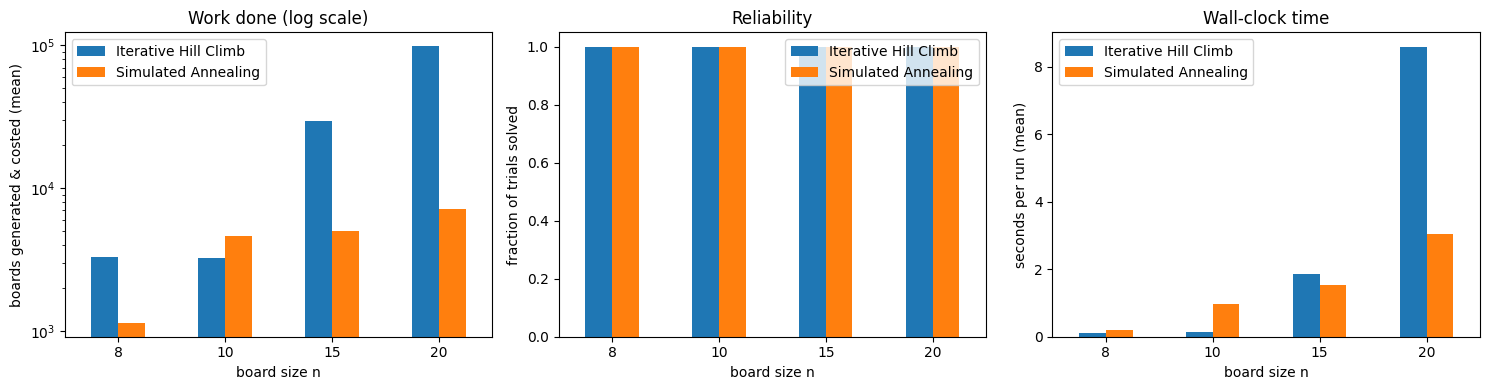

In [13]:
# Side-by-side view of the shared metric (states generated) and success rate
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pivot = summary.reset_index()
for name, ax, col, ylabel in [
    ("states",  axes[0], "avg_states",   "boards generated & costed (mean)"),
    ("success", axes[1], "success_rate", "fraction of trials solved"),
    ("time",    axes[2], "avg_time_s",   "seconds per run (mean)"),
]:
    pivot.pivot(index="n", columns="algorithm", values=col).plot.bar(ax=ax, rot=0)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("board size n")
    ax.legend(title=None)

axes[0].set_yscale("log")
axes[0].set_title("Work done (log scale)")
axes[1].set_title("Reliability")
axes[1].set_ylim(0, 1.05)
axes[2].set_title("Wall-clock time")
plt.tight_layout()
plt.show()

In [14]:
#Another local search method applied to this problem: Genetic Algorithms

class GeneticSolver:
    """
    Genetic algorithm (R&N 4.1.4, Figure 4.8). Instead of one board, keep a whole
    POPULATION of boards. Each generation: pick parents (fitter ones more often),
    splice them together to make children, occasionally mutate a child, and the
    children become the next generation.

    The idea that makes it different from everything so far: CROSSOVER. If one
    parent has queens 0-2 placed well and another has queens 3-7 placed well,
    splicing them can produce a child better than either. R&N call these useful
    chunks "schemas". Whether they exist in a problem is the whole question.
    """

    def __init__(self, n=8, population_size=100, mutation_rate=0.1, elitism=2):
        self.n = n
        self.population_size = population_size
        self.mutation_rate = mutation_rate     # chance a child gets one random queen moved
        self.elitism = elitism                 # top-k parents copied straight into next gen
        self.max_pairs = n * (n - 1) // 2      # 28 for n=8: every pair non-attacking
        self.generations = 0
        self.states_generated = 0

    @staticmethod
    def attacking_pairs(ind):
        """
        R&N's actual heuristic: number of PAIRS of queens attacking each other.
        Same three checks as EightQueensState.cost() (row, upper diag, lower
        diag, looking rightwards) but with np.sum instead of np.any, so three
        queens on one row count as 3 pairs, not 1. See the notes below on why
        this matters for a GA specifically.
        """
        s, n, count = ind.state, ind.n, 0
        for i in range(n - 1):
            d = np.arange(1, n - i)
            rest = s[i + 1:]
            count += int(np.sum(rest == s[i]) + np.sum(rest == s[i] + d) + np.sum(rest == s[i] - d))
        return count

    def fitness(self, ind):
        """
        Fitness MAXIMISES - the sign flip. 28 - attacking_pairs, so a solution
        scores 28 and worse boards score less. R&N Fig 4.6(b) uses exactly this.

        Cached on the object because one individual gets scored several times
        per generation (weights, elitism sort, best-of-generation). Without the
        cache the GA is several times slower for no reason.
        """
        if not hasattr(ind, '_fit'):
            ind._fit = self.max_pairs - self.attacking_pairs(ind)
        return ind._fit

    @staticmethod
    def reproduce(p1, p2):
        """
        R&N's REPRODUCE, Fig 4.8. Pick a crossover point c, take columns [0, c)
        from parent 1 and [c, n) from parent 2.

            p1 = 3 2 7 | 5 2 4 1 1        c = 3
            p2 = 2 4 7 | 4 8 5 5 2
            child = 3 2 7 4 8 5 5 2       <- Fig 4.6(d), first child

        Note the book's PROSE says crossover makes two children (this one and
        the mirror image). The PSEUDOCODE returns one. Following the pseudocode.
        randint(1, n) keeps c in [1, n-1], so both parents contribute something.
        """
        c = np.random.randint(1, p1.n)
        return EightQueensState(np.concatenate([p1.state[:c], p2.state[c:]]))

    def solve(self, max_generations=1000):
        # (a) initial population - random boards
        population = [EightQueensState(n=self.n) for _ in range(self.population_size)]
        self.states_generated = self.population_size
        best = max(population, key=self.fitness)

        for gen in range(1, max_generations + 1):
            self.generations = gen
            if best.is_goal():
                return best

            # (b) fitness -> selection probabilities. WEIGHTED-BY in Fig 4.8.
            # Normalise so they sum to 1; np.random.choice needs that.
            weights = np.array([self.fitness(i) for i in population], dtype=float)
            probs = weights / weights.sum()

            new_pop = []

            # Elitism (R&N mention it, Fig 4.8 doesn't do it). Copy the best few
            # parents forward unchanged. Guarantees best fitness never DROPS
            # between generations, which otherwise happens constantly - a good
            # board breeds, its children are worse, and it's gone.
            if self.elitism:
                new_pop.extend(sorted(population, key=self.fitness, reverse=True)[:self.elitism])

            while len(new_pop) < self.population_size:
                # (c) WEIGHTED-RANDOM-CHOICES: two parents, fitter ones more
                # likely. Same individual can be picked twice; some are never
                # picked - exactly what Fig 4.6(c) shows.
                i, j = np.random.choice(len(population), size=2, p=probs)

                # (d) crossover
                child = self.reproduce(population[i], population[j])

                # (e) mutation - "choose a queen at random and move it to a
                # random square in its column". That's random_neighbour(),
                # unchanged. Third algorithm to reuse it.
                if np.random.random() < self.mutation_rate:
                    child = child.random_neighbour()

                new_pop.append(child)
                self.states_generated += 1      # one child built and scored

            population = new_pop
            gb = max(population, key=self.fitness)
            if self.fitness(gb) > self.fitness(best):
                best = gb

        return best          # ran out of generations - hand back the best seen

In [15]:
solver = GeneticSolver(n=8)
solution = solver.solve()

print(solution)
print("generations:", solver.generations)
print("states generated:", solver.states_generated)

Goal state! [6 3 1 4 7 0 2 5]
generations: 39
states generated: 3824
